# Phase 1-2: Time Series Pattern & Feature Analysis
## Tutorial: Understanding Your Data to Choose the Right Model

**Goal**: By the end of this notebook, you'll understand:
- What patterns exist in your sales data (trends, seasonality, cycles)
- Which features are most predictive of future sales
- What types of models would work best for your forecasting problem

**What we'll cover**:
1. Load data with all engineered features
2. **Phase 1: Time Series Pattern Analysis**
   - Basic time series plots
   - Trend and seasonality decomposition
   - Day-of-week and monthly patterns
   - Autocorrelation analysis
3. **Phase 2: Feature Engineering Validation**
   - Correlation analysis
   - Feature importance
   - Lag feature relationships

---
## Setup: Import Libraries and Load Data

In [1]:
# Standard data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Time series specific
from statsmodels.tsa.seasonal import STL  # For decomposition
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf  # For autocorrelation

# Machine learning (for feature importance)
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

# Your custom modules
from doughflow.data.make_dataset import load_raw_data, aggregate_daily_level
from doughflow.features.build_features import (
    ProductFeatureExtractor,
    TemporalFeatureExtractor,
    LagFeatureExtractor
)

# Plot settings for better visuals
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 6)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


### Step 1: Load and Prepare Data with All Features

**What we're doing**: Running your full feature engineering pipeline to create all the features we designed (temporal, lag, rolling statistics).

**Why**: We need all features to understand which ones actually help predict sales.

In [2]:
# Load raw data and aggregate to daily level
print("Loading raw data...")
raw_data = load_raw_data('../data/raw')
daily_data = aggregate_daily_level(raw_data)

print(f"Loaded {len(daily_data)} daily records")
print(f"Date range: {daily_data['date'].min()} to {daily_data['date'].max()}")

Loading raw data...
Loaded 35008 daily records
Date range: 2021-01-02 to 2025-10-30


In [34]:
# Create feature engineering pipeline
print("Building feature engineering pipeline...")

pipeline = Pipeline([
    ('product', ProductFeatureExtractor(aggregation_level='item')),
    ('temporal', TemporalFeatureExtractor()),
    ('lag', LagFeatureExtractor(
        recent_lag_weeks=[1, 2, 3, 4],  # 1-4 weeks ago
        yearly_lags=[1, 2],              # 1-2 years ago same week
        fill_strategy='cascading'        # Smart missing value handling
    ))
])

# Transform data
print("Extracting features...")
df = pipeline.fit_transform(daily_data)

# get only data from Thusday to Sunday 
df = df[df['day_of_week'].isin([3,4,5,6])]

print(f"\n✅ Feature engineering complete!")
print(f"   Shape: {df.shape}")
print(f"   Columns: {list(df.columns)}")

Building feature engineering pipeline...
Extracting features...

✅ Feature engineering complete!
   Shape: (1661, 17)
   Columns: ['date', 'item', 'quantity', 'day_of_week', 'day_of_month', 'month', 'year', 'week_of_year', 'is_weekend', 'lag_1w_ago', 'lag_2w_ago', 'lag_3w_ago', 'lag_4w_ago', 'lag_1y_same_week', 'lag_2y_same_week', 'rolling_mean_7d', 'rolling_std_7d']


In [35]:
# Quick preview of the data
print("\nFirst few rows of processed data:")
df.head(10)


First few rows of processed data:


,date,item,quantity,day_of_week,day_of_month,month,year,week_of_year,is_weekend,lag_1w_ago,lag_2w_ago,lag_3w_ago,lag_4w_ago,lag_1y_same_week,lag_2y_same_week,rolling_mean_7d,rolling_std_7d
0,2021-05-13,Croissant,42,3,13,5,2021,19,False,52.95,52.95,52.95,52.95,52.95,52.95,0.00,0.00
1,2021-05-14,Croissant,61,4,14,5,2021,19,False,42.00,42.00,42.00,42.00,52.95,52.95,42.00,0.00
2,2021-05-15,Croissant,100,5,15,5,2021,19,True,51.50,51.50,51.50,51.50,52.95,52.95,51.50,13.44
3,2021-05-16,Croissant,53,6,16,5,2021,19,True,67.67,67.67,67.67,67.67,52.95,52.95,67.67,29.57
6,2021-05-20,Croissant,19,3,20,5,2021,20,False,42.00,54.83,54.83,54.83,52.95,52.95,54.83,26.07
7,2021-05-21,Croissant,52,4,21,5,2021,20,False,61.00,49.71,49.71,49.71,52.95,52.95,49.71,27.38
8,2021-05-22,Croissant,94,5,22,5,2021,20,True,100.00,51.14,51.14,51.14,52.95,52.95,51.14,27.17
9,2021-05-23,Croissant,47,6,23,5,2021,20,True,53.00,55.86,55.86,55.86,52.95,52.95,55.86,31.66
12,2021-05-27,Croissant,40,3,27,5,2021,21,False,19.00,42.00,47.86,47.86,52.95,52.95,47.86,23.50
13,2021-05-28,Croissant,80,4,28,5,2021,21,False,52.00,61.00,46.14,46.14,52.95,52.95,46.14,23.59


---
# PHASE 1: Time Series Pattern Analysis

**Big Picture Question**: *Does your data have predictable patterns that a model can learn?*

We're looking for:
- **Trend**: Is there an overall upward/downward direction?
- **Seasonality**: Do sales repeat on a weekly, monthly, or yearly cycle?
- **Autocorrelation**: Do past values predict future values?

These patterns determine which models will work best.

## 1.1: Basic Time Series Visualization

**What to look for**:
- Overall trends (increasing, decreasing, flat)
- Seasonal patterns (repeating peaks and valleys)
- Outliers or unusual events
- Differences between Danish and Croissant patterns

In [36]:
# Separate Danish and Croissant data
danish = df[df['item'] == 'Danish'].copy()
croissant = df[df['item'] == 'Croissant'].copy()

print(f"Danish records: {len(danish)}")
print(f"Croissant records: {len(croissant)}")

Danish records: 818
Croissant records: 843


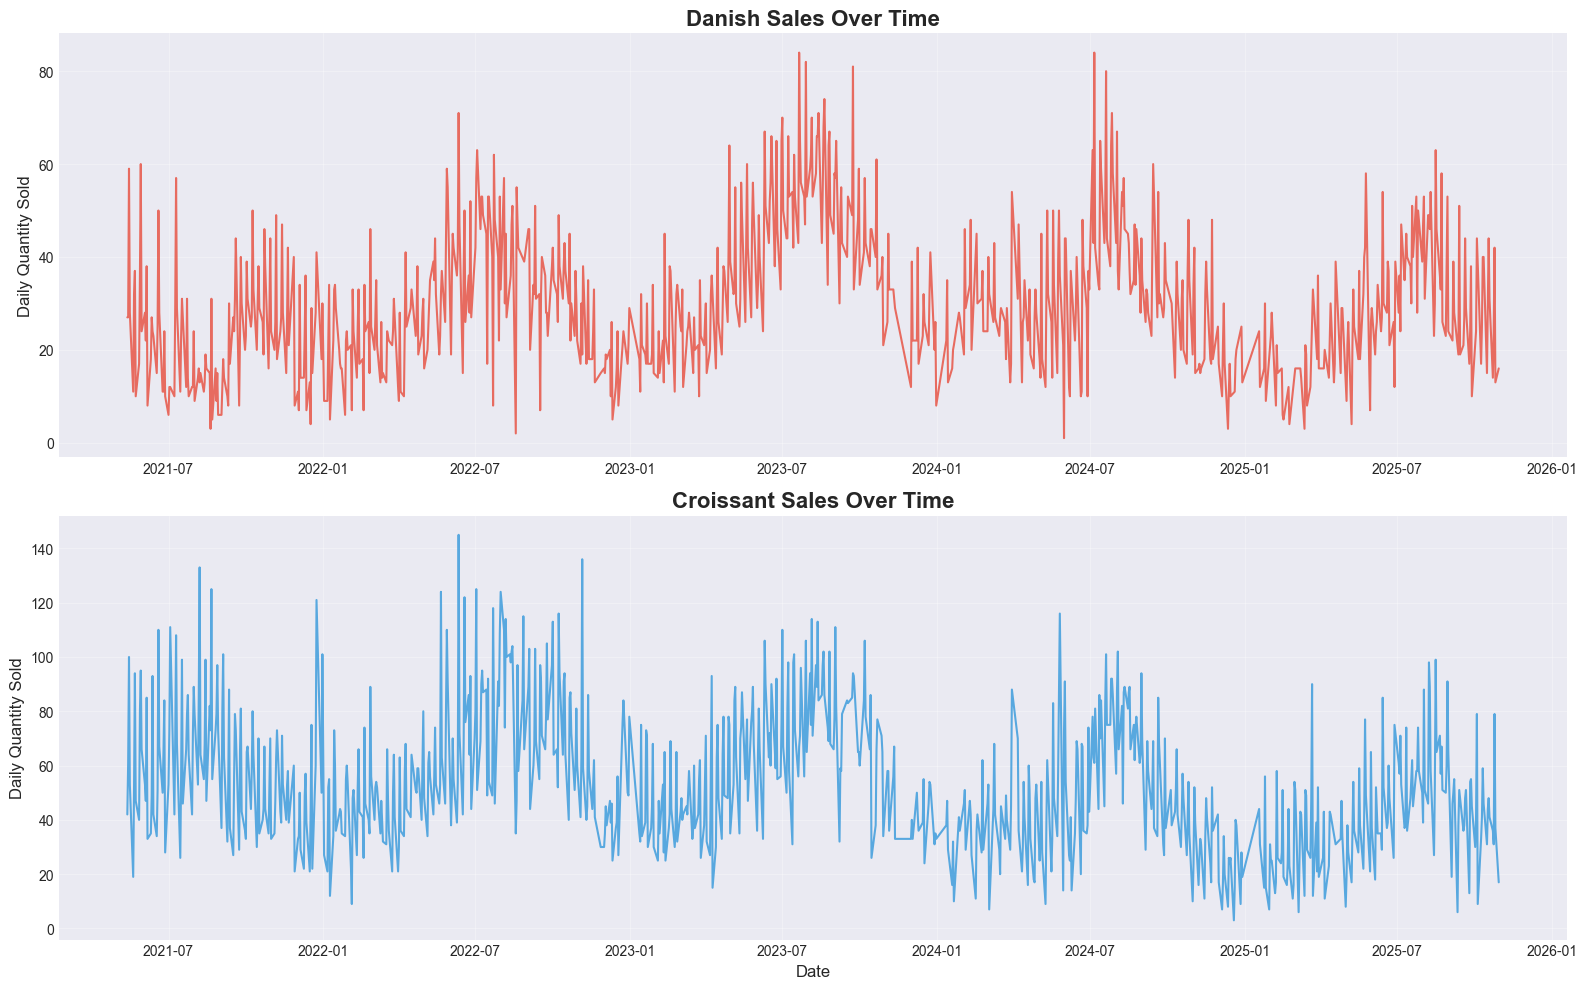

In [37]:
# Plot 1: Side-by-side time series
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Danish sales over time
axes[0].plot(danish['date'], danish['quantity'], linewidth=1.5, alpha=0.8, color='#e74c3c')
axes[0].set_title('Danish Sales Over Time', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Daily Quantity Sold', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Croissant sales over time
axes[1].plot(croissant['date'], croissant['quantity'], linewidth=1.5, alpha=0.8, color='#3498db')
axes[1].set_title('Croissant Sales Over Time', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Daily Quantity Sold', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Danish & Croissant follow similar patterns across 5 years of sales as they move along with the seasons which they peak in Summer and early Fall but have much lower sales in Winter and Sring. Therefore, they don't need to be trained in different models.

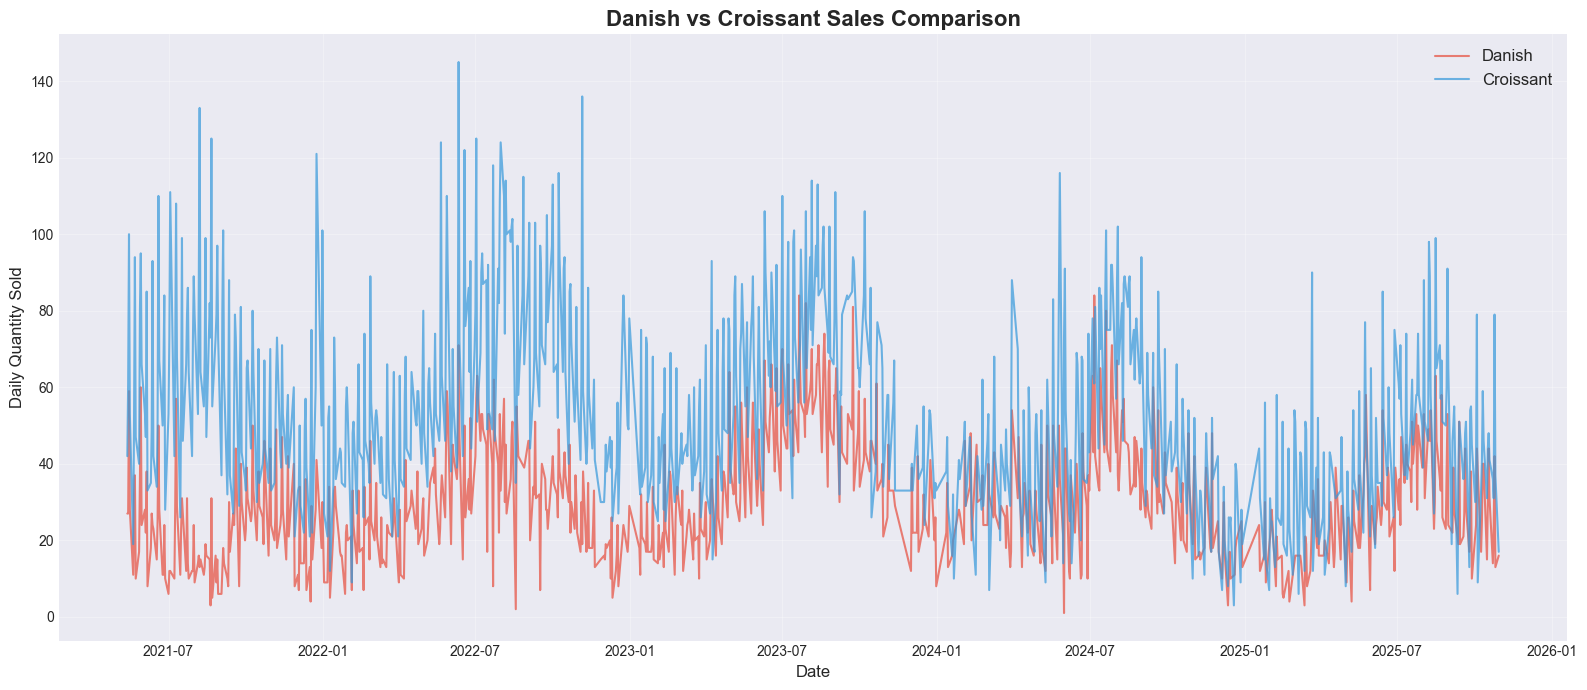

In [38]:
# Plot 2: Overlaid comparison
plt.figure(figsize=(16, 7))
plt.plot(danish['date'], danish['quantity'], label='Danish', linewidth=1.5, alpha=0.7, color='#e74c3c')
plt.plot(croissant['date'], croissant['quantity'], label='Croissant', linewidth=1.5, alpha=0.7, color='#3498db')

plt.title('Danish vs Croissant Sales Comparison', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily Quantity Sold', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Both Danish and Croissant sales move together, but Croissant has much more sales Danish. Therefore, model training could be separated as parameters could be different.

## 1.2: Trend & Seasonality Decomposition (STL)

**What is STL Decomposition?**  
It separates your time series into 3 components:
1. **Trend**: Long-term direction (are sales growing or declining?)
2. **Seasonal**: Repeating patterns (weekly cycles, monthly patterns)
3. **Residual**: Random noise (what's left after removing trend + seasonality)

**Why this matters**:  
- Strong seasonal component → Use seasonal features or SARIMA models
- Strong trend → Need models that handle non-stationarity (differencing, Prophet)
- Large residuals → High unpredictability, may need external features

/var/folders/29/j8y5fr5n52976t5qhqnb312c0000gn/T/ipykernel_63450/3573189257.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  danish_ts = danish_ts.fillna(method='ffill')


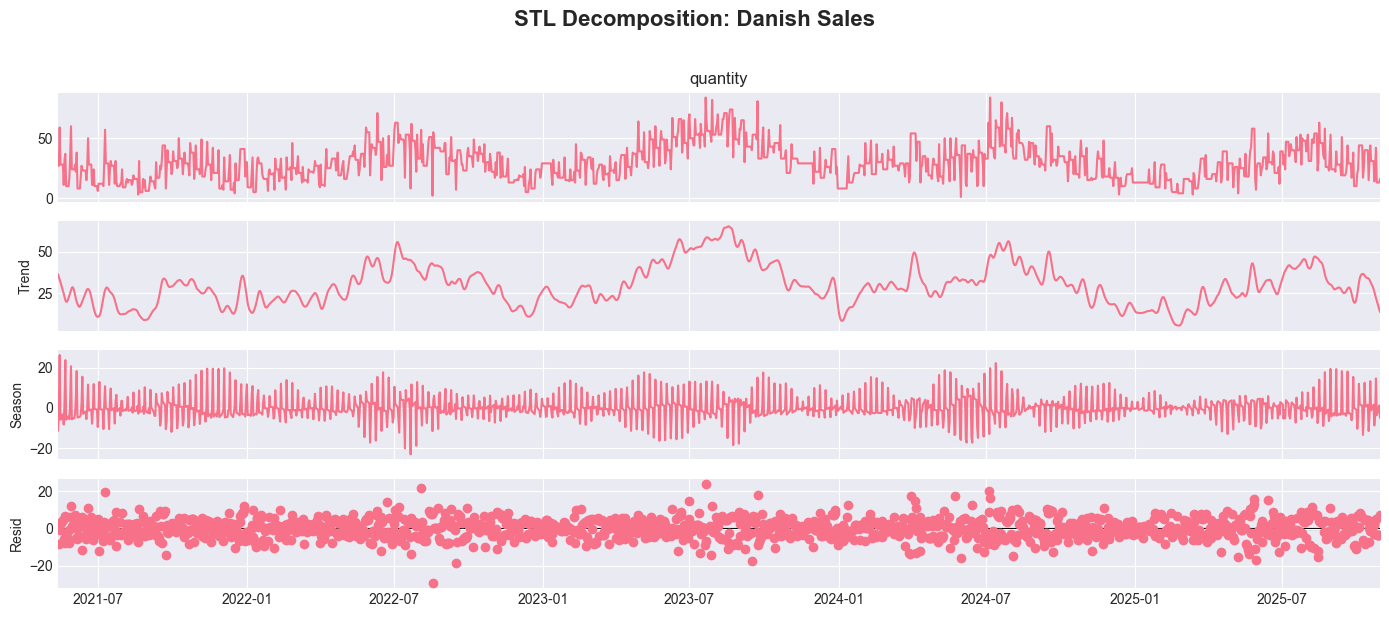


📊 HOW TO READ THIS:
1️⃣ OBSERVED: Original data (what you actually measured)
2️⃣ TREND: Smooth long-term movement
   → Upward slope = growing sales | Downward = declining | Flat = stable
3️⃣ SEASONAL: Repeating weekly pattern
   → Regular up/down cycles = strong seasonality
   → Larger amplitude = stronger weekly effects
4️⃣ RESIDUAL: Random variation (noise)
   → Small residuals = predictable data | Large residuals = lots of randomness


In [39]:
# STL Decomposition for Danish
# Note: STL requires evenly spaced time series, so we set date as index
danish_ts = danish.set_index('date')['quantity'].asfreq('D')  # 'D' = daily frequency

# Fill any missing dates with forward fill (in case of gaps)
danish_ts = danish_ts.fillna(method='ffill')

# Perform STL decomposition
# seasonal=7 means we expect weekly seasonality (7 days)
stl_danish = STL(danish_ts, seasonal=7)
result_danish = stl_danish.fit()

# Plot decomposition
fig = result_danish.plot()
fig.suptitle('STL Decomposition: Danish Sales', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 HOW TO READ THIS:")
print("====================")
print("1️⃣ OBSERVED: Original data (what you actually measured)")
print("2️⃣ TREND: Smooth long-term movement")
print("   → Upward slope = growing sales | Downward = declining | Flat = stable")
print("3️⃣ SEASONAL: Repeating weekly pattern")
print("   → Regular up/down cycles = strong seasonality")
print("   → Larger amplitude = stronger weekly effects")
print("4️⃣ RESIDUAL: Random variation (noise)")
print("   → Small residuals = predictable data | Large residuals = lots of randomness")

Danish sales move up and down according to the seasons changing with higher demands in summer.

/var/folders/29/j8y5fr5n52976t5qhqnb312c0000gn/T/ipykernel_63450/318599700.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  croissant_ts = croissant.set_index('date')['quantity'].asfreq('D').fillna(method='ffill')


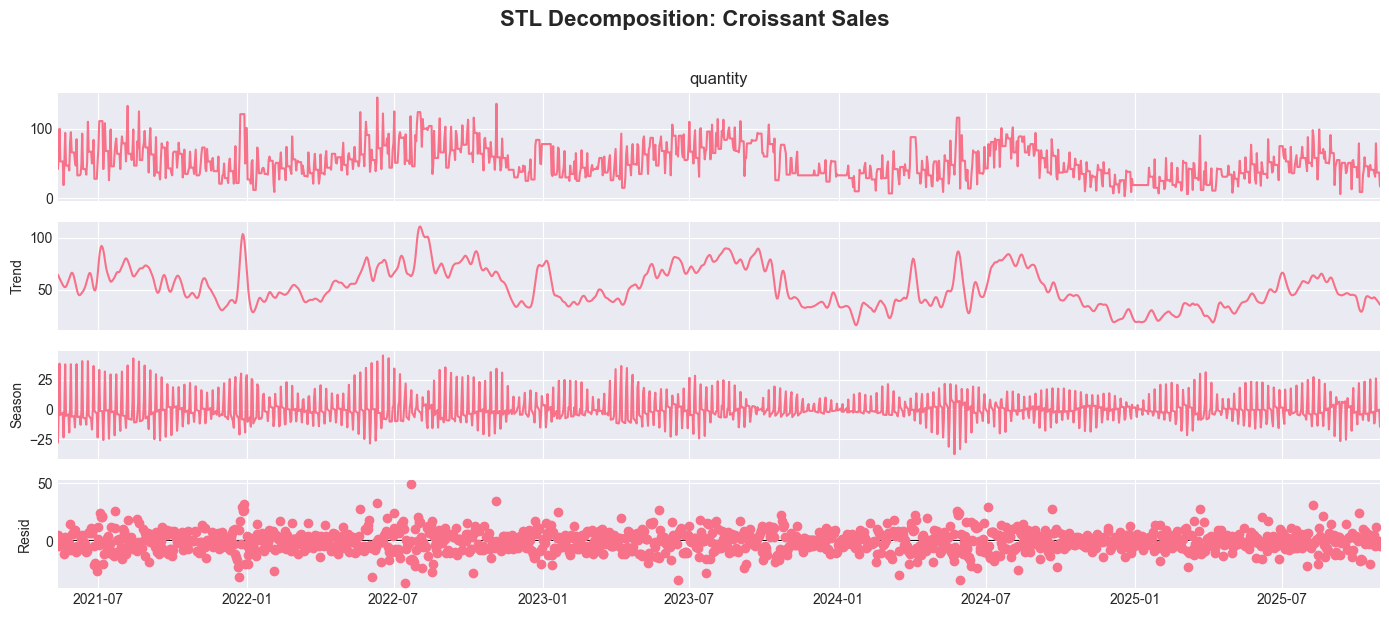

In [41]:
# STL Decomposition for Croissant
croissant_ts = croissant.set_index('date')['quantity'].asfreq('D').fillna(method='ffill')

stl_croissant = STL(croissant_ts, seasonal=7)
result_croissant = stl_croissant.fit()

fig = result_croissant.plot()
fig.suptitle('STL Decomposition: Croissant Sales', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Croissant sales also move along with the seasons, but its pattern is spreaded through out the years more than Danish which likely to have more demands only in the Summer and Fall. 

In [44]:
# Calculate strength of trend and seasonality
def calculate_strength(result):
    """Calculate strength of trend and seasonality (0-1 scale)"""
    var_resid = np.var(result.resid)
    var_detrend = np.var(result.resid + result.seasonal)
    var_deseason = np.var(result.resid + result.trend)
    
    strength_trend = max(0, 1 - var_deseason / var_detrend)
    strength_seasonal = max(0, 1 - var_detrend / var_deseason)
    
    return strength_trend, strength_seasonal

st_danish, ss_danish = calculate_strength(result_danish)
st_croissant, ss_croissant = calculate_strength(result_croissant)

print("\n📈 STRENGTH METRICS (0 = weak, 1 = strong):")
print("=============================================")
print(f"\nDANISH:")
print(f"  Trend Strength:      {st_danish:.3f}")
print(f"  Seasonal Strength:   {ss_danish:.3f}")
print(f"\nCROISSANT:")
print(f"  Trend Strength:      {st_croissant:.3f}")
print(f"  Seasonal Strength:   {ss_croissant:.3f}")

print("\n💡 MODEL IMPLICATIONS:")
print("======================")
if ss_danish > 0.6 or ss_croissant > 0.6:
    print("✅ Strong seasonality detected → Lag features (1w, 2w ago) will be VERY useful")
    print("   Consider: SARIMA, Prophet, or ML models with lag features")
else:
    print("⚠️ Weak seasonality → May need external features (promotions, holidays)")

if st_danish > 0.6 or st_croissant > 0.6:
    print("✅ Strong trend detected → Need trend-aware models")
    print("   Consider: Prophet, ARIMA with differencing, or polynomial features")
else:
    print("⚠️ Weak trend → Stationary models (simple ARMA) may work")


📈 STRENGTH METRICS (0 = weak, 1 = strong):

DANISH:
  Trend Strength:      0.000
  Seasonal Strength:   0.666

CROISSANT:
  Trend Strength:      0.000
  Seasonal Strength:   0.567

💡 MODEL IMPLICATIONS:
✅ Strong seasonality detected → Lag features (1w, 2w ago) will be VERY useful
   Consider: SARIMA, Prophet, or ML models with lag features
⚠️ Weak trend → Stationary models (simple ARMA) may work


## 1.3: Day-of-Week Patterns

**Why this matters**: Bakeries often have strong day-of-week effects (weekends vs weekdays, Friday spikes, etc.)

**What to look for**:
- Are weekends higher/lower than weekdays?
- Is there a specific peak day (e.g., Saturday mornings)?
- Consistency in patterns (tight boxes = predictable, wide boxes = variable)

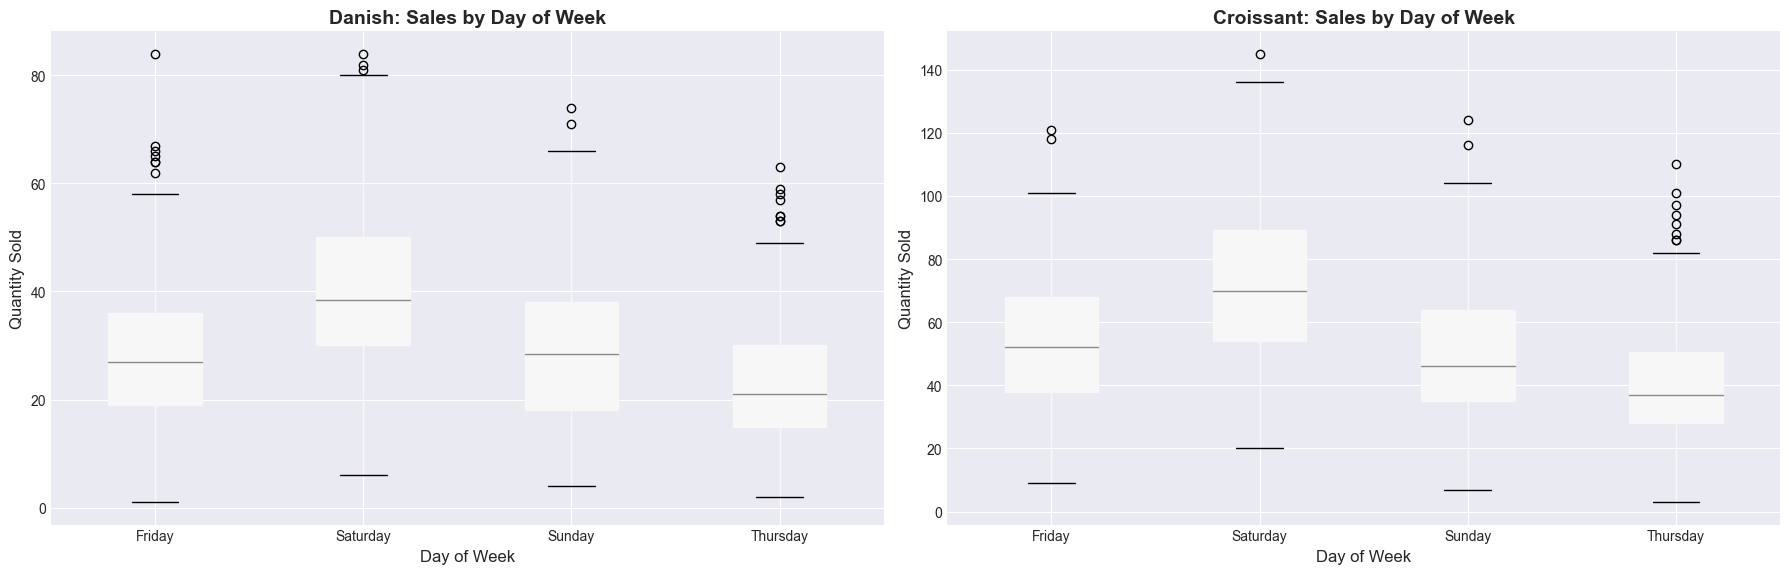


📊 HOW TO INTERPRET:
📦 BOX PLOT ELEMENTS:
   - Box = middle 50% of sales (25th to 75th percentile)
   - Line in box = median (typical sales for that day)
   - Whiskers = range of normal variation
   - Dots = outliers (unusual days)

❓ QUESTIONS TO ASK:
   1. Which day has highest median sales?
   2. Are weekends different from weekdays?
   3. Are boxes tight (predictable) or wide (variable)?


In [52]:
# Create day names for better visualization
day_mapping = {
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
}
danish['day_name'] = danish['day_of_week'].map(day_mapping)
croissant['day_name'] = croissant['day_of_week'].map(day_mapping)

# Create box plots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Danish day-of-week pattern
danish.boxplot(column='quantity', by='day_name', ax=axes[0], 
               patch_artist=True, )
axes[0].set_title('Danish: Sales by Day of Week', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Day of Week', fontsize=12)
axes[0].set_ylabel('Quantity Sold', fontsize=12)
axes[0].get_figure().suptitle('')  # Remove default title

# Croissant day-of-week pattern
croissant.boxplot(column='quantity', by='day_name', ax=axes[1],
                  patch_artist=True)
axes[1].set_title('Croissant: Sales by Day of Week', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Day of Week', fontsize=12)
axes[1].set_ylabel('Quantity Sold', fontsize=12)
axes[1].get_figure().suptitle('')

plt.tight_layout()
plt.show()

print("\n📊 HOW TO INTERPRET:")
print("====================")
print("📦 BOX PLOT ELEMENTS:")
print("   - Box = middle 50% of sales (25th to 75th percentile)")
print("   - Line in box = median (typical sales for that day)")
print("   - Whiskers = range of normal variation")
print("   - Dots = outliers (unusual days)\n")
print("❓ QUESTIONS TO ASK:")
print("   1. Which day has highest median sales?")
print("   2. Are weekends different from weekdays?")
print("   3. Are boxes tight (predictable) or wide (variable)?")

Even though Croissant has more demands than Danish, they both share high demands on weekends than weekdays with boxes are wide which implies the data points are variable. Saturdays are peaked for both of items with Danish has median of 40 sales and Croisssant's is about 70.

In [55]:
# day order
day_order = ['Thursday', 'Friday', 'Saturday', 'Sunday']

# Calculate statistics by day of week
print("\n📊 DANISH - Average Sales by Day:")
print("==================================")
danish_by_day = danish.groupby('day_name')['quantity'].agg(['mean', 'std', 'median'])
danish_by_day = danish_by_day.reindex(day_order)
print(danish_by_day.round(2))

print("\n📊 CROISSANT - Average Sales by Day:")
print("=====================================")
croissant_by_day = croissant.groupby('day_name')['quantity'].agg(['mean', 'std', 'median'])
croissant_by_day = croissant_by_day.reindex(day_order)
print(croissant_by_day.round(2))

# Find peak day
peak_day_danish = danish_by_day['mean'].idxmax()
peak_day_croissant = croissant_by_day['mean'].idxmax()

print(f"\n💡 KEY INSIGHT:")
print(f"   Peak day for Danish: {peak_day_danish}")
print(f"   Peak day for Croissant: {peak_day_croissant}")
print(f"\n   → 'day_of_week' feature will be IMPORTANT for your model!")


📊 DANISH - Average Sales by Day:
           mean    std  median
day_name                      
Thursday  23.78  12.40    21.0
Friday    28.36  13.93    27.0
Saturday  39.87  15.13    38.5
Sunday    29.26  14.25    28.5

📊 CROISSANT - Average Sales by Day:
           mean    std  median
day_name                      
Thursday  40.87  20.54    37.0
Friday    53.63  22.03    52.0
Saturday  72.63  24.05    70.0
Sunday    49.44  21.32    46.0

💡 KEY INSIGHT:
   Peak day for Danish: Saturday
   Peak day for Croissant: Saturday

   → 'day_of_week' feature will be IMPORTANT for your model!


## 1.4: Monthly Seasonality

**Why check monthly patterns?**
- Seasonal ingredients (e.g., pumpkin in fall)
- Holiday effects (Christmas, Valentine's Day)
- Weather patterns (cold months vs warm months)

If monthly patterns are strong, you may need yearly lag features (lag_1y_same_week).

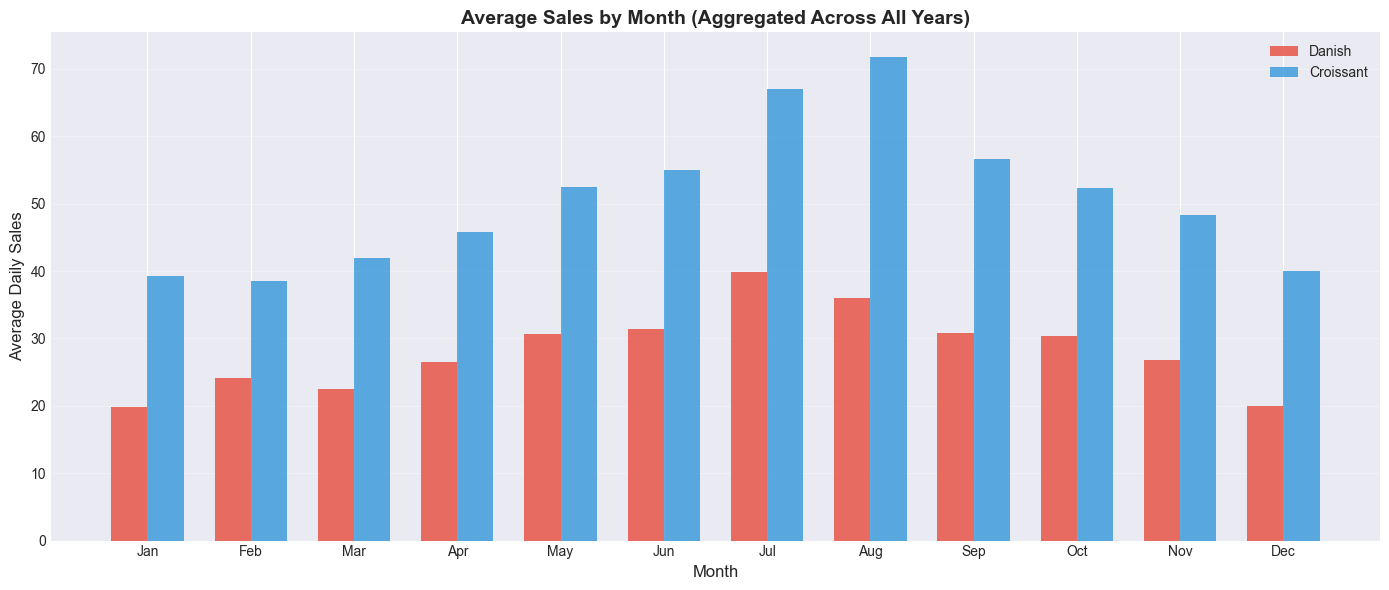


📊 INTERPRETATION:
❓ Are there clear peaks in certain months?
   → YES = Seasonal effects exist, consider lag_1y_same_week feature
❓ Are summer months different from winter?
   → Temperature/weather may be a factor
❓ Do Danish and Croissant have same monthly pattern?
   → Similar patterns = shared external factors


In [14]:
# Add month names
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
danish['month_name'] = danish['month'].map(lambda x: month_names[x-1])
croissant['month_name'] = croissant['month'].map(lambda x: month_names[x-1])

# Calculate average by month
danish_by_month = danish.groupby('month_name')['quantity'].mean().reindex(month_names)
croissant_by_month = croissant.groupby('month_name')['quantity'].mean().reindex(month_names)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(month_names))
width = 0.35

ax.bar(x - width/2, danish_by_month, width, label='Danish', alpha=0.8, color='#e74c3c')
ax.bar(x + width/2, croissant_by_month, width, label='Croissant', alpha=0.8, color='#3498db')

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Average Daily Sales', fontsize=12)
ax.set_title('Average Sales by Month (Aggregated Across All Years)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(month_names)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n📊 INTERPRETATION:")
print("==================")
print("❓ Are there clear peaks in certain months?")
print("   → YES = Seasonal effects exist, consider lag_1y_same_week feature")
print("❓ Are summer months different from winter?")
print("   → Temperature/weather may be a factor")
print("❓ Do Danish and Croissant have same monthly pattern?")
print("   → Similar patterns = shared external factors")

## 1.5: Autocorrelation Analysis (ACF & PACF)

**What is Autocorrelation?**  
It measures how much today's sales are related to sales from X days ago.

**Why this is CRITICAL**:
- **ACF (Autocorrelation Function)**: Shows correlation at different lags
- **PACF (Partial Autocorrelation)**: Shows direct relationship after removing intermediate lags

**What to look for**:
- Spike at lag 7 → Strong weekly pattern (sales similar to last week)
- Slow decay → Trending data (need differencing for ARIMA)
- Sharp cutoff → Helps determine ARIMA parameters (p, q values)

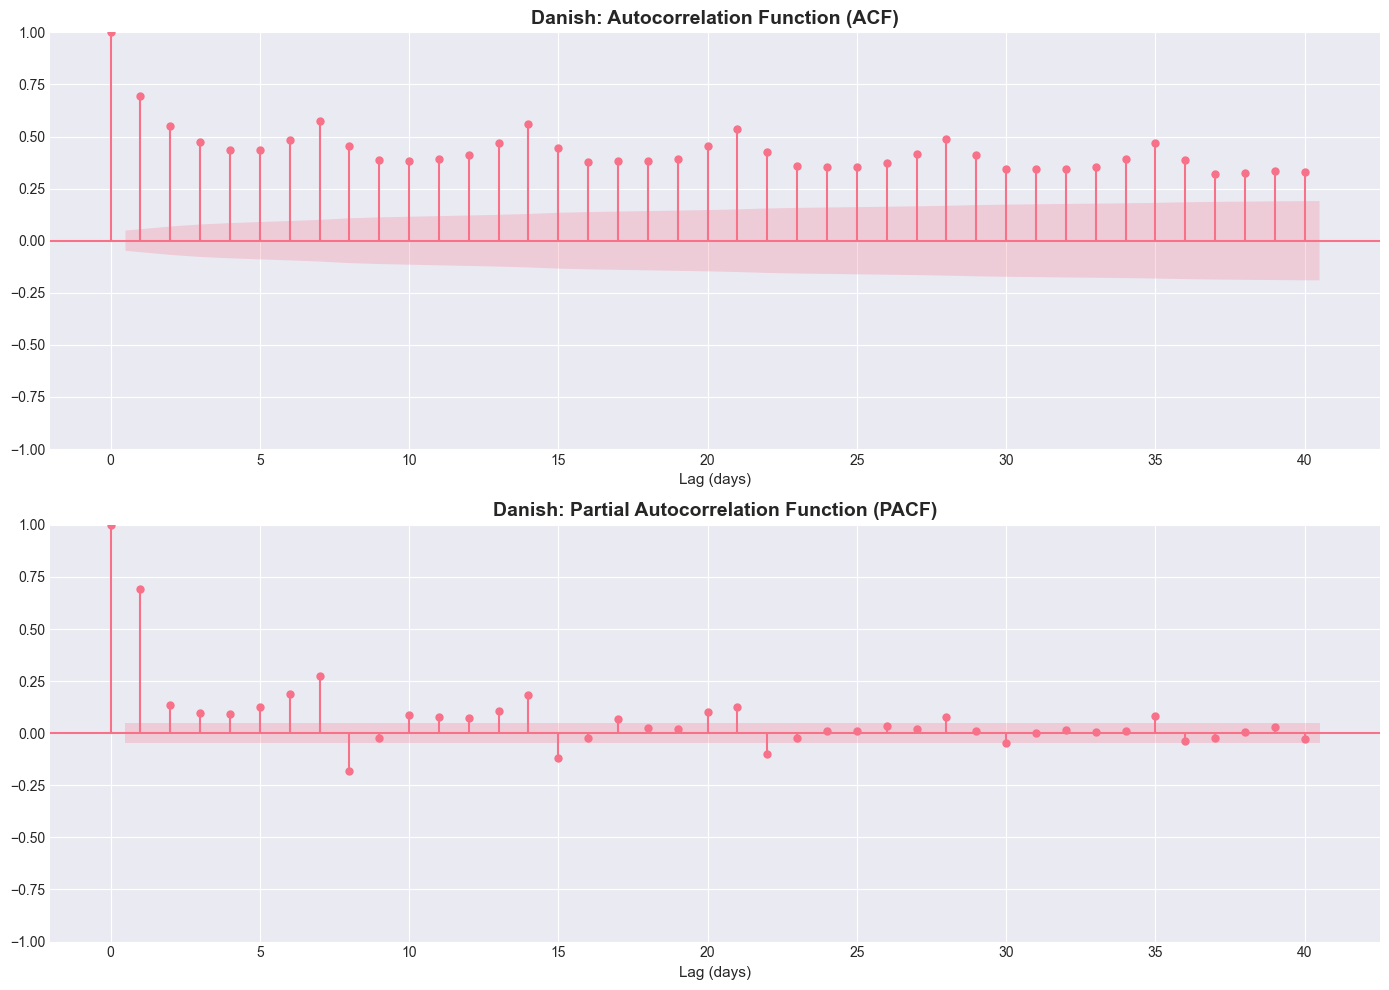


📊 HOW TO READ ACF/PACF:

📈 The blue shaded area = significance threshold
   - Bars OUTSIDE the blue area = statistically significant correlation
   - Bars INSIDE the blue area = not significant (likely noise)

🔍 WHAT TO LOOK FOR:
   1️⃣ Spike at lag 7? → Strong WEEKLY pattern
      → Your lag_1w_ago feature will be very powerful!
   2️⃣ Spikes at lag 14, 21, 28? → Confirms multi-week seasonality
      → lag_2w_ago, lag_3w_ago, lag_4w_ago features are useful
   3️⃣ Slow linear decay in ACF? → Trending data
      → May need differencing or trend features
   4️⃣ Sharp cutoff in PACF? → Tells you how many lag terms an ARIMA model needs


In [15]:
# ACF and PACF for Danish
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ACF
plot_acf(danish_ts.dropna(), lags=40, ax=axes[0], alpha=0.05)
axes[0].set_title('Danish: Autocorrelation Function (ACF)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Lag (days)', fontsize=11)

# PACF
plot_pacf(danish_ts.dropna(), lags=40, ax=axes[1], alpha=0.05)
axes[1].set_title('Danish: Partial Autocorrelation Function (PACF)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Lag (days)', fontsize=11)

plt.tight_layout()
plt.show()

print("\n📊 HOW TO READ ACF/PACF:")
print("=========================")
print("\n📈 The blue shaded area = significance threshold")
print("   - Bars OUTSIDE the blue area = statistically significant correlation")
print("   - Bars INSIDE the blue area = not significant (likely noise)\n")
print("🔍 WHAT TO LOOK FOR:")
print("   1️⃣ Spike at lag 7? → Strong WEEKLY pattern")
print("      → Your lag_1w_ago feature will be very powerful!")
print("   2️⃣ Spikes at lag 14, 21, 28? → Confirms multi-week seasonality")
print("      → lag_2w_ago, lag_3w_ago, lag_4w_ago features are useful")
print("   3️⃣ Slow linear decay in ACF? → Trending data")
print("      → May need differencing or trend features")
print("   4️⃣ Sharp cutoff in PACF? → Tells you how many lag terms an ARIMA model needs")

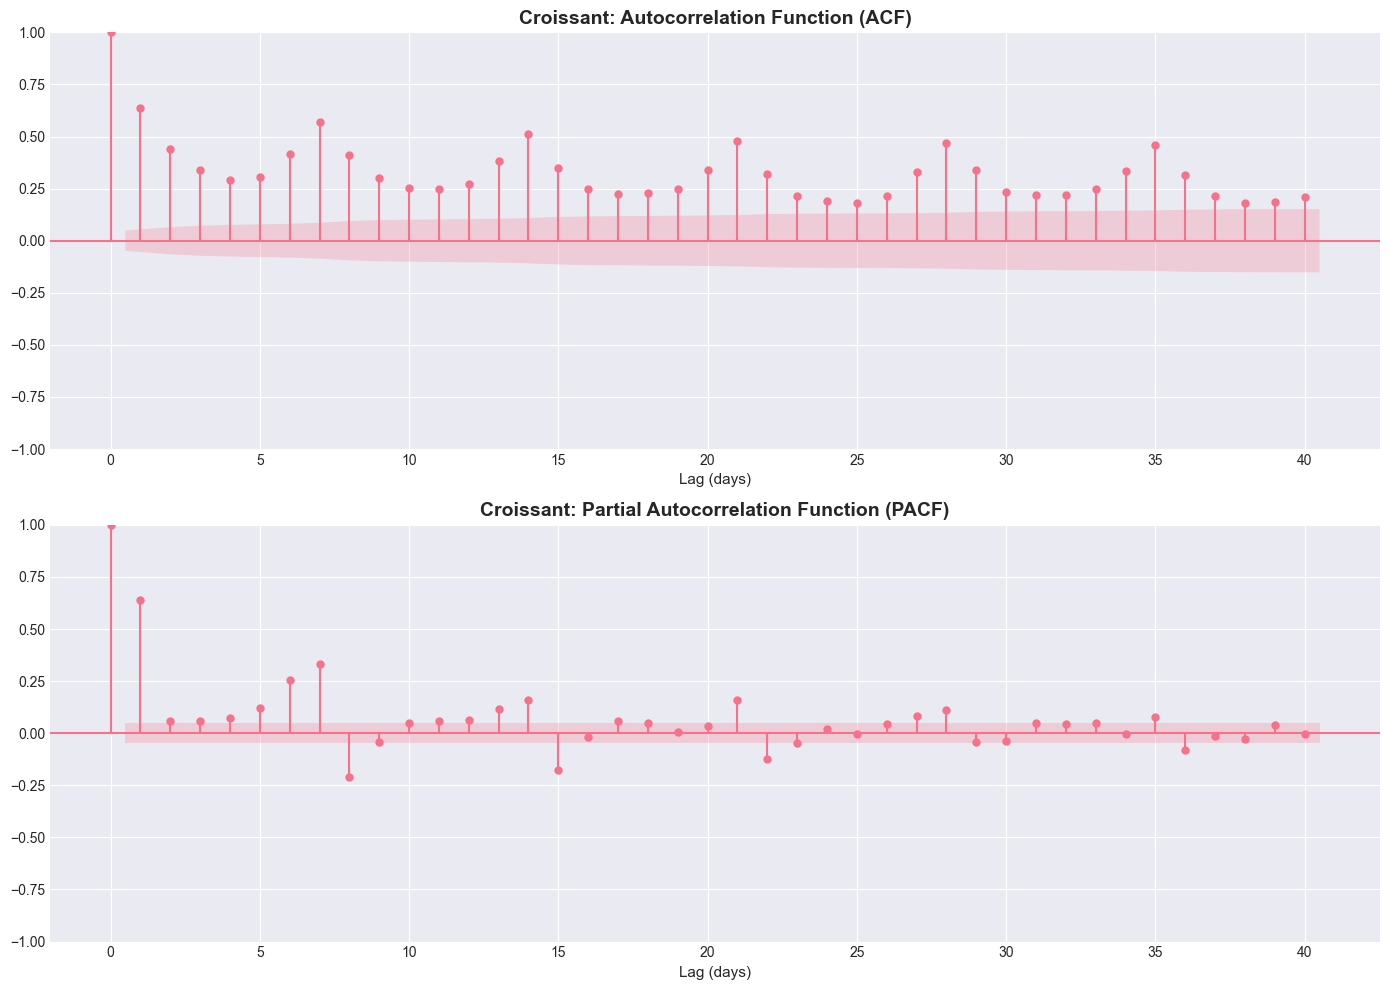

In [16]:
# ACF and PACF for Croissant
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

plot_acf(croissant_ts.dropna(), lags=40, ax=axes[0], alpha=0.05)
axes[0].set_title('Croissant: Autocorrelation Function (ACF)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Lag (days)', fontsize=11)

plot_pacf(croissant_ts.dropna(), lags=40, ax=axes[1], alpha=0.05)
axes[1].set_title('Croissant: Partial Autocorrelation Function (PACF)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Lag (days)', fontsize=11)

plt.tight_layout()
plt.show()

There is a strong weekly and multi-week patterns as ACF shows spikes a lag 7, 14, 21,... across Danish and Croissant. 

---
# PHASE 2: Feature Engineering Validation

**Big Question**: *Do the features we created actually help predict sales?*

We'll validate:
1. Correlation between lag features and target (quantity)
2. Which features are most important
3. Relationships between features and sales

## 2.1: Correlation Heatmap

**What is correlation?**
- Measures linear relationship between two variables (-1 to +1)
- +1 = perfect positive relationship (when X goes up, Y goes up)
- -1 = perfect negative relationship (when X goes up, Y goes down)
- 0 = no linear relationship

**What we want to see**:
- High correlation between lag features (lag_1w_ago, lag_2w_ago) and quantity
- This validates that past sales predict future sales

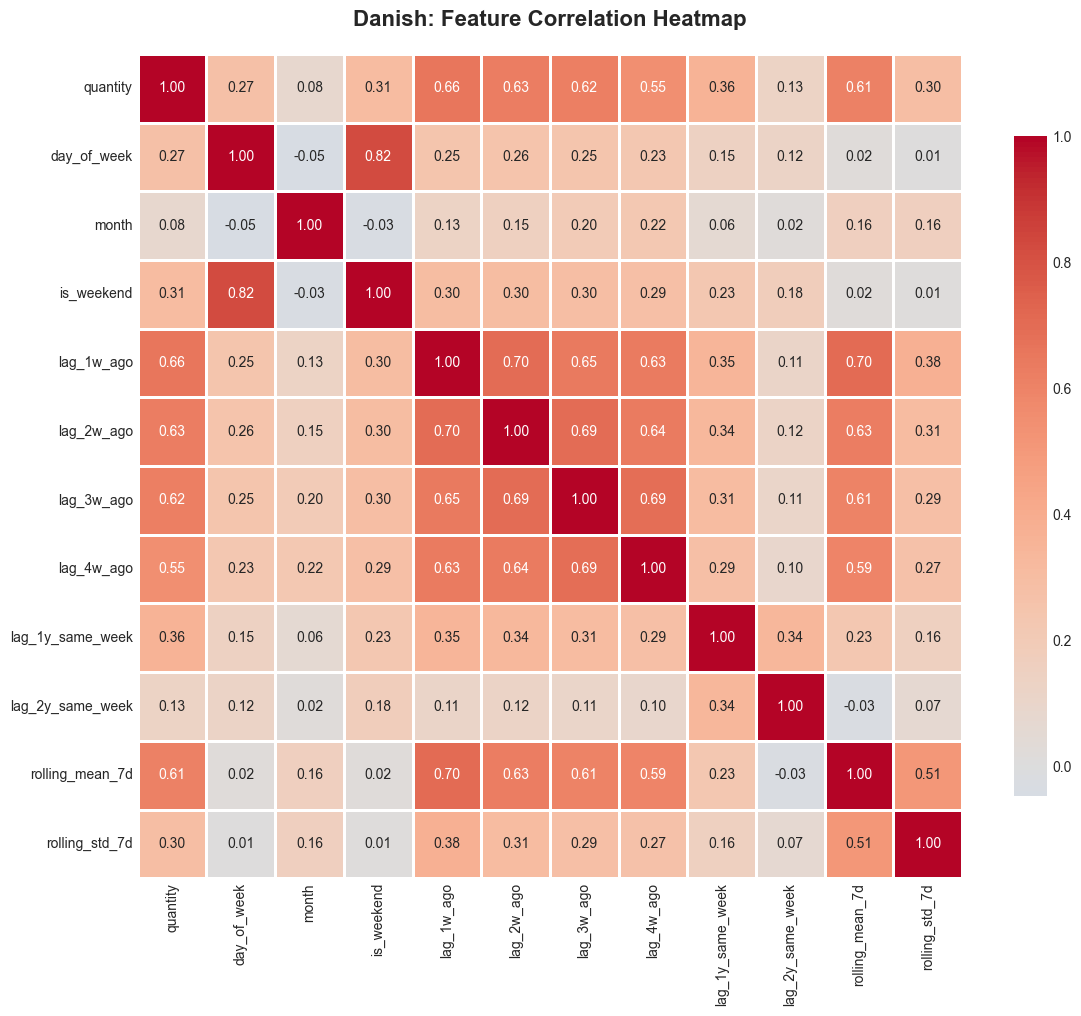


📊 HOW TO READ THE HEATMAP:
🎨 COLOR GUIDE:
   - Red = Positive correlation (move together)
   - Blue = Negative correlation (move opposite)
   - White = No correlation

🎯 WHAT TO FOCUS ON: Look at the 'quantity' row/column
   → Which features have correlation > 0.5 with quantity?
   → These are your most predictive features!


In [17]:
# Select numeric columns for correlation
numeric_cols = [
    'quantity',           # TARGET
    'day_of_week',
    'month',
    'is_weekend',
    'lag_1w_ago',
    'lag_2w_ago',
    'lag_3w_ago',
    'lag_4w_ago',
    'lag_1y_same_week',
    'lag_2y_same_week',
    'rolling_mean_7d',
    'rolling_std_7d'
]

# Calculate correlation for Danish
corr_danish = danish[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_danish, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Danish: Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n📊 HOW TO READ THE HEATMAP:")
print("============================")
print("🎨 COLOR GUIDE:")
print("   - Red = Positive correlation (move together)")
print("   - Blue = Negative correlation (move opposite)")
print("   - White = No correlation\n")
print("🎯 WHAT TO FOCUS ON: Look at the 'quantity' row/column")
print("   → Which features have correlation > 0.5 with quantity?")
print("   → These are your most predictive features!")


📊 DANISH - Features ranked by correlation with sales:
lag_1w_ago          0.663078
lag_2w_ago          0.631322
lag_3w_ago          0.619222
rolling_mean_7d     0.608740
lag_4w_ago          0.548192
lag_1y_same_week    0.362431
is_weekend          0.312137
rolling_std_7d      0.295517
day_of_week         0.274274
lag_2y_same_week    0.131857
month               0.083117
Name: quantity, dtype: float64


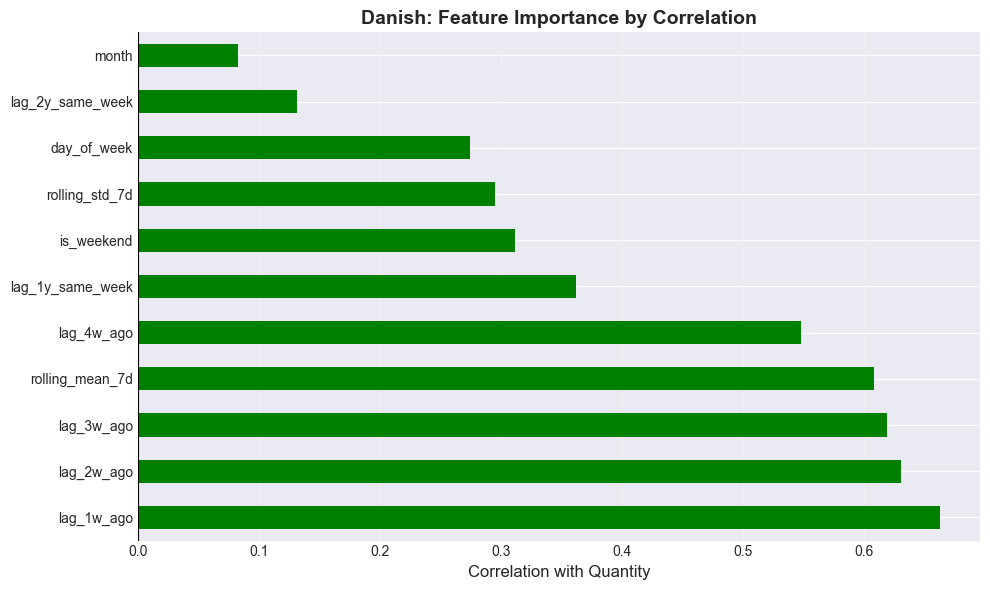


💡 INTERPRETATION:
✅ Most correlated feature: lag_1w_ago (r = 0.663)
   → MODERATE predictor. Useful but not perfect.


In [19]:
# Extract correlation with target and sort
target_corr_danish = corr_danish['quantity'].drop('quantity').sort_values(ascending=False)

print("\n📊 DANISH - Features ranked by correlation with sales:")
print("=======================================================")
print(target_corr_danish)

# Visualize as bar chart
plt.figure(figsize=(10, 6))
target_corr_danish.plot(kind='barh', color=['green' if x > 0 else 'red' for x in target_corr_danish])
plt.xlabel('Correlation with Quantity', fontsize=12)
plt.title('Danish: Feature Importance by Correlation', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n💡 INTERPRETATION:")
print("==================")
top_feature = target_corr_danish.idxmax()
top_corr = target_corr_danish.max()
print(f"✅ Most correlated feature: {top_feature} (r = {top_corr:.3f})")
if top_corr > 0.7:
    print("   → STRONG predictor! This feature is very valuable.")
elif top_corr > 0.5:
    print("   → MODERATE predictor. Useful but not perfect.")
else:
    print("   → WEAK predictors. May need external features (weather, promotions).")

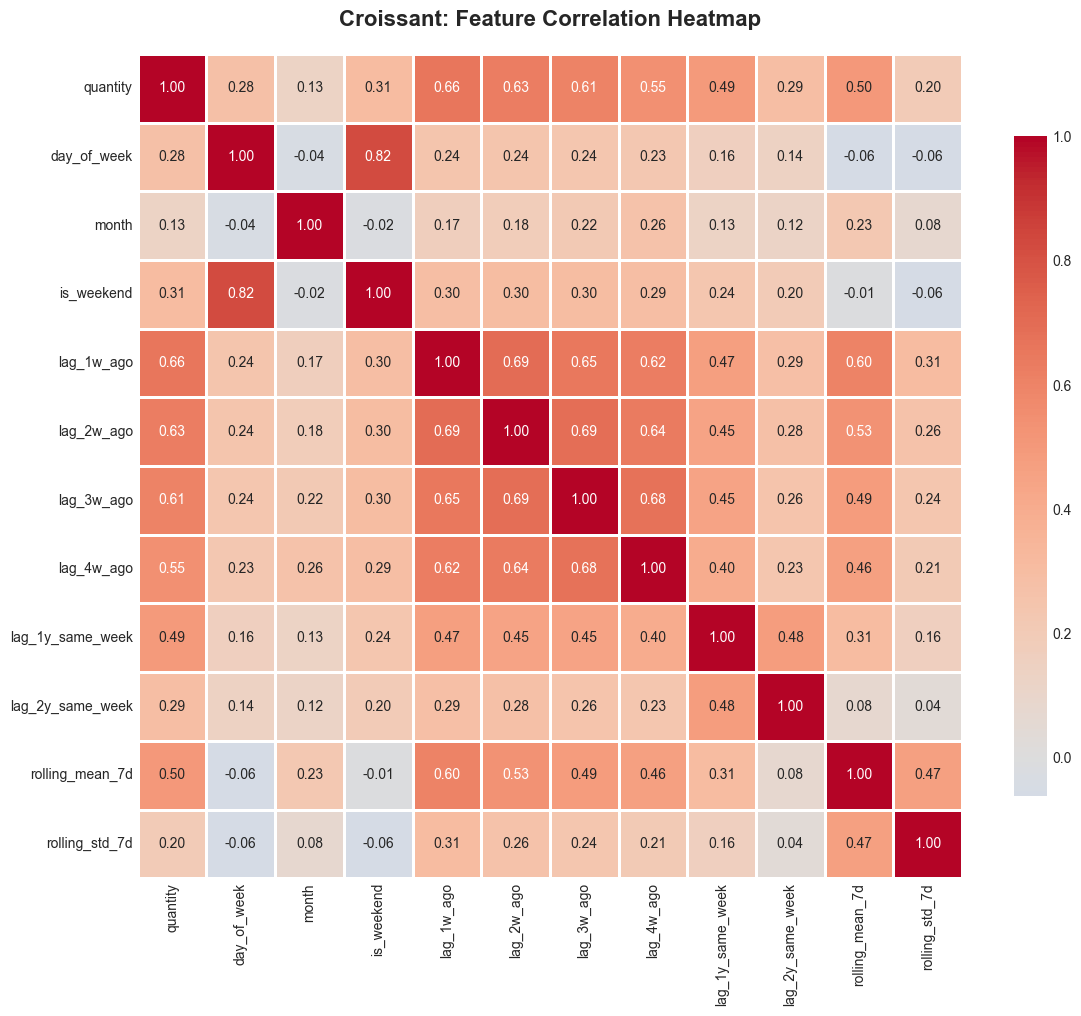


📊 CROISSANT - Features ranked by correlation with sales:
lag_1w_ago          0.657292
lag_2w_ago          0.627481
lag_3w_ago          0.608244
lag_4w_ago          0.547083
rolling_mean_7d     0.502433
lag_1y_same_week    0.493179
is_weekend          0.308647
lag_2y_same_week    0.294074
day_of_week         0.275123
rolling_std_7d      0.202894
month               0.133350
Name: quantity, dtype: float64


In [20]:
# Same analysis for Croissant
corr_croissant = croissant[numeric_cols].corr()
target_corr_croissant = corr_croissant['quantity'].drop('quantity').sort_values(ascending=False)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_croissant, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Croissant: Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n📊 CROISSANT - Features ranked by correlation with sales:")
print("==========================================================")
print(target_corr_croissant)

## 2.2: Scatter Plots - Target vs Key Features

**Why scatter plots?**
Correlation only captures LINEAR relationships. Scatter plots reveal:
- Non-linear patterns
- Outliers
- Strength of relationship visually

We'll plot quantity vs most important features.

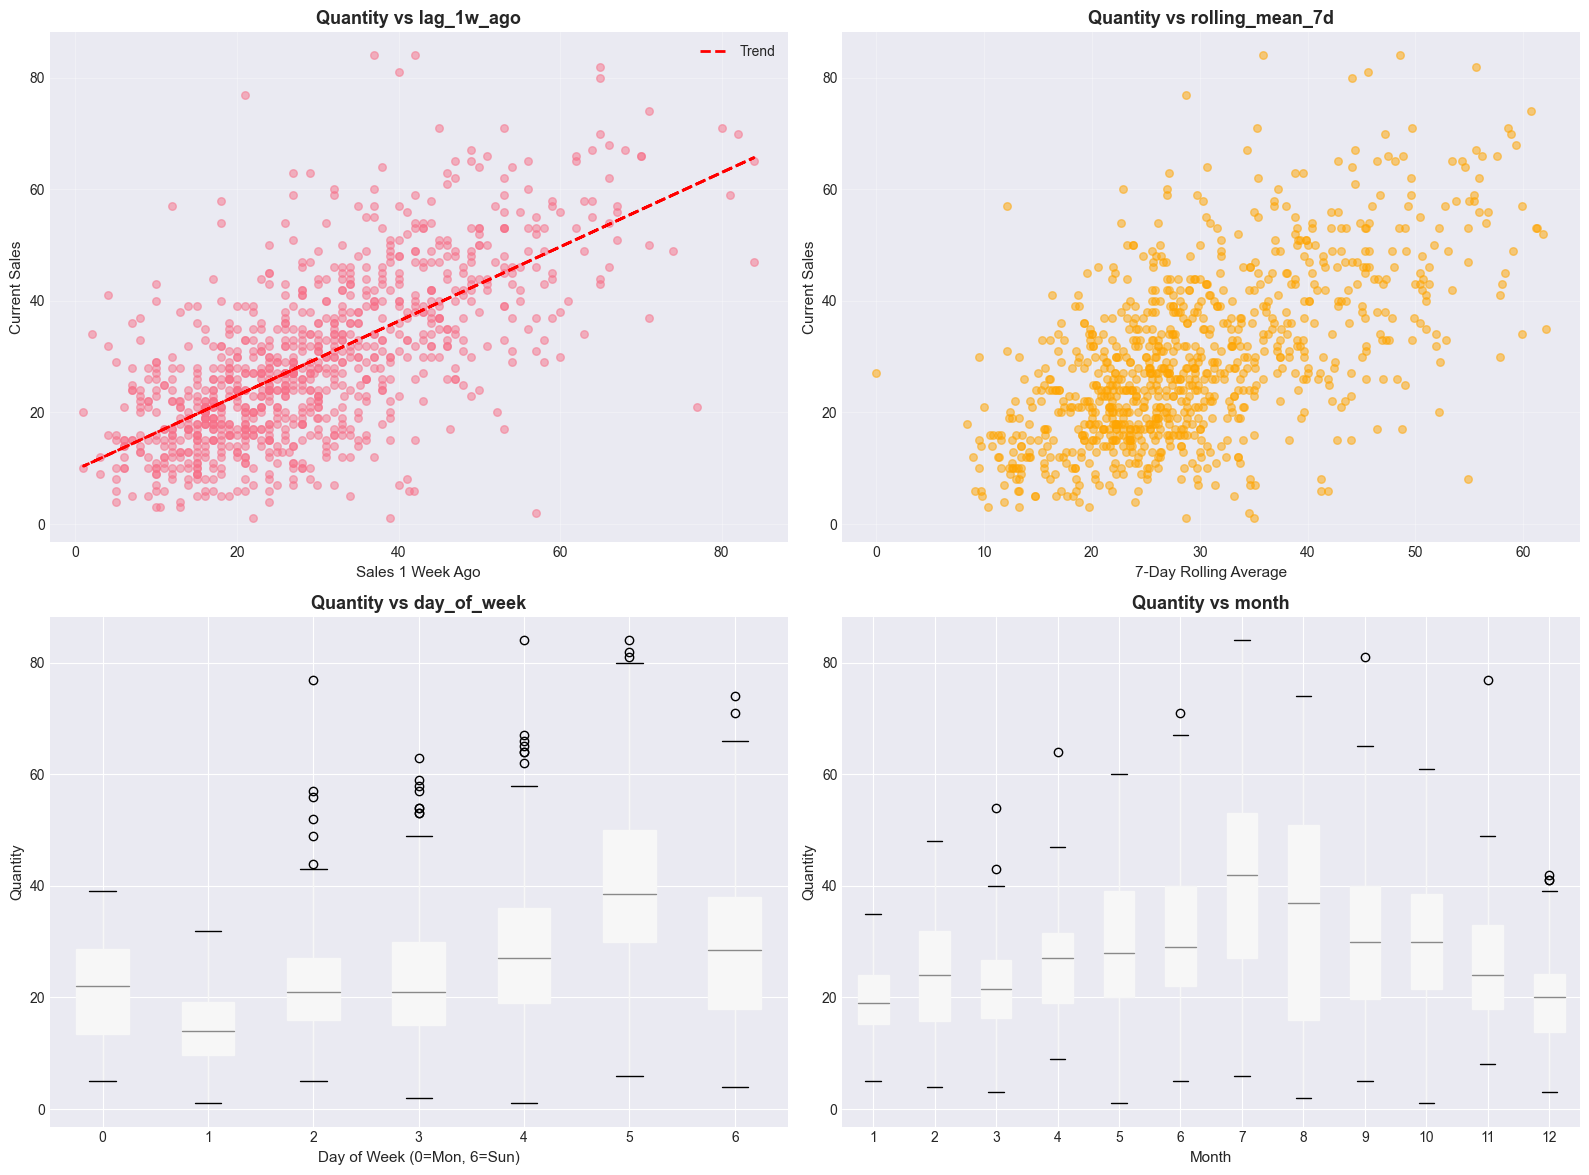


📊 WHAT TO LOOK FOR:
1️⃣ lag_1w_ago scatter: Do points cluster around the trend line?
   → Tight cluster = strong predictive power
   → Scattered = weak relationship

2️⃣ rolling_mean_7d: Similar pattern to lag features?
   → Shows if recent average is a good predictor

3️⃣ day_of_week: Clear differences between days?
   → Big differences = important feature

4️⃣ month: Seasonal differences?
   → Variation = yearly patterns exist


In [21]:
# Danish: Quantity vs Lag Features
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: lag_1w_ago
axes[0, 0].scatter(danish['lag_1w_ago'], danish['quantity'], alpha=0.5, s=30)
axes[0, 0].set_xlabel('Sales 1 Week Ago', fontsize=11)
axes[0, 0].set_ylabel('Current Sales', fontsize=11)
axes[0, 0].set_title('Quantity vs lag_1w_ago', fontsize=13, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(danish['lag_1w_ago'].dropna(), danish[danish['lag_1w_ago'].notna()]['quantity'], 1)
p = np.poly1d(z)
axes[0, 0].plot(danish['lag_1w_ago'], p(danish['lag_1w_ago']), "r--", linewidth=2, label='Trend')
axes[0, 0].legend()

# Plot 2: rolling_mean_7d
axes[0, 1].scatter(danish['rolling_mean_7d'], danish['quantity'], alpha=0.5, s=30, color='orange')
axes[0, 1].set_xlabel('7-Day Rolling Average', fontsize=11)
axes[0, 1].set_ylabel('Current Sales', fontsize=11)
axes[0, 1].set_title('Quantity vs rolling_mean_7d', fontsize=13, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: day_of_week (box plot)
danish.boxplot(column='quantity', by='day_of_week', ax=axes[1, 0], patch_artist=True)
axes[1, 0].set_xlabel('Day of Week (0=Mon, 6=Sun)', fontsize=11)
axes[1, 0].set_ylabel('Quantity', fontsize=11)
axes[1, 0].set_title('Quantity vs day_of_week', fontsize=13, fontweight='bold')
axes[1, 0].get_figure().suptitle('')

# Plot 4: month
danish.boxplot(column='quantity', by='month', ax=axes[1, 1], patch_artist=True)
axes[1, 1].set_xlabel('Month', fontsize=11)
axes[1, 1].set_ylabel('Quantity', fontsize=11)
axes[1, 1].set_title('Quantity vs month', fontsize=13, fontweight='bold')
axes[1, 1].get_figure().suptitle('')

plt.tight_layout()
plt.show()

print("\n📊 WHAT TO LOOK FOR:")
print("====================")
print("1️⃣ lag_1w_ago scatter: Do points cluster around the trend line?")
print("   → Tight cluster = strong predictive power")
print("   → Scattered = weak relationship\n")
print("2️⃣ rolling_mean_7d: Similar pattern to lag features?")
print("   → Shows if recent average is a good predictor\n")
print("3️⃣ day_of_week: Clear differences between days?")
print("   → Big differences = important feature\n")
print("4️⃣ month: Seasonal differences?")
print("   → Variation = yearly patterns exist")

## 2.3: Feature Importance with Random Forest

**What is Feature Importance?**
- Random Forest is a tree-based model that can rank features by how useful they are for prediction
- Higher importance = more valuable for making predictions

**Why this is different from correlation:**
- Correlation only measures linear relationships
- Random Forest captures non-linear patterns and feature interactions

This is a **quick preview** of which features will help your final model.

In [56]:
# Prepare data for Random Forest (Danish)
# Drop rows with missing lag features
danish_clean = danish[numeric_cols].dropna()

X = danish_clean.drop('quantity', axis=1)
y = danish_clean['quantity']

print(f"Training Random Forest on {len(X)} samples with {len(X.columns)} features...")

# Train a simple Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X, y)

# Get feature importances
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print("\n✅ Model trained!")
print(f"   R² Score: {rf.score(X, y):.3f}")
print("   (Note: This is on training data, so it's optimistic. We'll do proper validation later.)")

Training Random Forest on 818 samples with 11 features...

✅ Model trained!
   R² Score: 0.889
   (Note: This is on training data, so it's optimistic. We'll do proper validation later.)


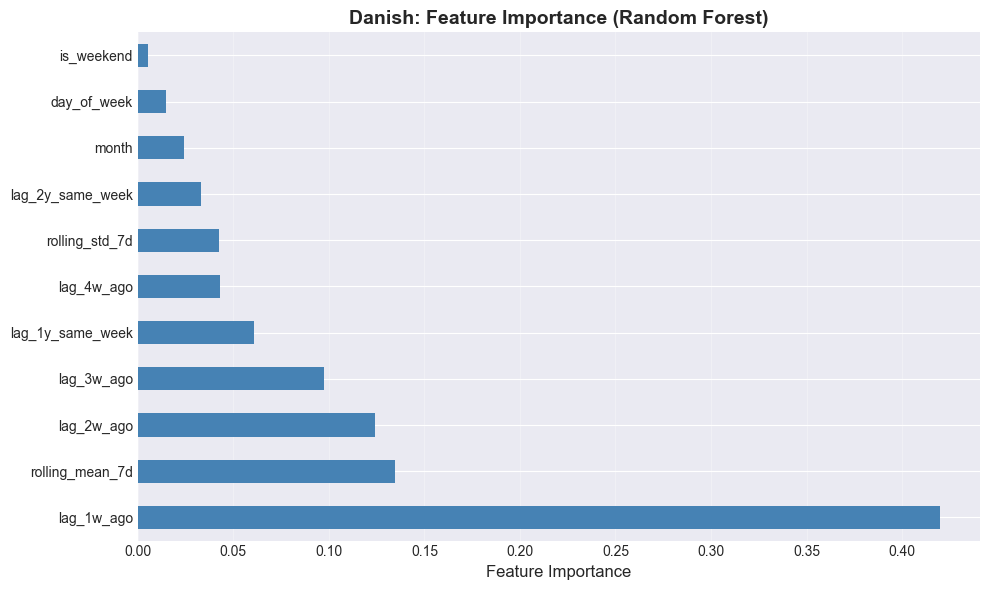


📊 DANISH - Feature Importance Rankings:
lag_1w_ago          0.419773
rolling_mean_7d     0.134665
lag_2w_ago          0.124042
lag_3w_ago          0.097563
lag_1y_same_week    0.060932
lag_4w_ago          0.043108
rolling_std_7d      0.042633
lag_2y_same_week    0.033052
month               0.024123
day_of_week         0.014914
is_weekend          0.005195
dtype: float64

💡 INTERPRETATION:
Top 3 most important features:
   1. lag_1w_ago: 0.420
   2. rolling_mean_7d: 0.135
   3. lag_2w_ago: 0.124

🎯 MODEL SELECTION INSIGHT:
✅ 'lag_1w_ago' is DOMINANT (>42.0% importance)
   → Simple models (Linear Regression, ARIMA) may work well


In [57]:
# Plot feature importances
plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='steelblue')
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Danish: Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n📊 DANISH - Feature Importance Rankings:")
print("=========================================")
print(importances)

print("\n💡 INTERPRETATION:")
print("==================")
print(f"Top 3 most important features:")
for i, (feat, imp) in enumerate(importances.head(3).items(), 1):
    print(f"   {i}. {feat}: {imp:.3f}")
    
print("\n🎯 MODEL SELECTION INSIGHT:")
if importances.iloc[0] > 0.4:
    print(f"✅ '{importances.index[0]}' is DOMINANT (>{importances.iloc[0]:.1%} importance)")
    print("   → Simple models (Linear Regression, ARIMA) may work well")
else:
    print("⚠️ Importance is distributed across many features")
    print("   → Complex models (XGBoost, Random Forest) may capture interactions better")

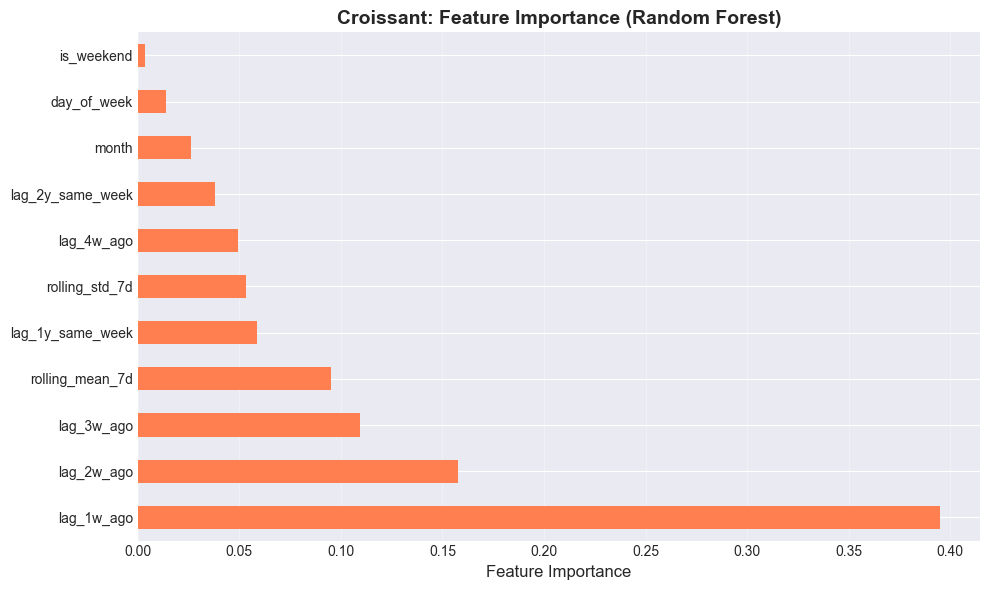


📊 CROISSANT - Feature Importance Rankings:
lag_1w_ago          0.394844
lag_2w_ago          0.157695
lag_3w_ago          0.109212
rolling_mean_7d     0.095245
lag_1y_same_week    0.058860
rolling_std_7d      0.053352
lag_4w_ago          0.049378
lag_2y_same_week    0.037920
month               0.026147
day_of_week         0.013996
is_weekend          0.003350
dtype: float64


In [58]:
# Same for Croissant
croissant_clean = croissant[numeric_cols].dropna()
X_c = croissant_clean.drop('quantity', axis=1)
y_c = croissant_clean['quantity']

rf_c = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_c.fit(X_c, y_c)
importances_c = pd.Series(rf_c.feature_importances_, index=X_c.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances_c.plot(kind='barh', color='coral')
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Croissant: Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n📊 CROISSANT - Feature Importance Rankings:")
print("============================================")
print(importances_c)